# Step 6: Landslide Susceptibility Mapping

In [2]:
import json, os, glob
import numpy as np
import pandas as pd
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

with open("watershed_analysis.json") as f:
    config = json.load(f)

stack_dir = os.path.join(config["output_dir"], "lsm_stack")

# Fix: find files with point_id suffix
csv_files = glob.glob(os.path.join(stack_dir, "lsm_training_samples_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No training samples CSV found in {stack_dir}")
print("Found training files:", csv_files)

data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Total samples: {len(data)}, Landslide: {data['label'].sum()}, Non-landslide: {(data['label']==0).sum()}")

X = data.drop(columns=["row", "col", "x", "y", "label", "point_id"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Found training files: ['results/lsm_stack/lsm_training_samples_1.csv']
Total samples: 16684, Landslide: 8342, Non-landslide: 8342
Train: 11678, Test: 5006


## Logistic Regression

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Fix: scale + more iterations
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])
lr.fit(X_train, y_train)
lr_pred = lr.predict_proba(X_test)[:, 1]
print("Logistic AUC:", roc_auc_score(y_test, lr_pred))
print(classification_report(y_test, (lr_pred > 0.5).astype(int)))

Logistic AUC: 0.8302323242000382
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      2456
           1       0.75      0.77      0.76      2550

    accuracy                           0.75      5006
   macro avg       0.75      0.75      0.75      5006
weighted avg       0.75      0.75      0.75      5006



## Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:,1]

print("RF AUC:", roc_auc_score(y_test, rf_pred))
print(classification_report(y_test, (rf_pred>0.5).astype(int)))


RF AUC: 0.9062446509548444
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2456
           1       0.81      0.88      0.84      2550

    accuracy                           0.83      5006
   macro avg       0.84      0.83      0.83      5006
weighted avg       0.84      0.83      0.83      5006



## Feature Importance

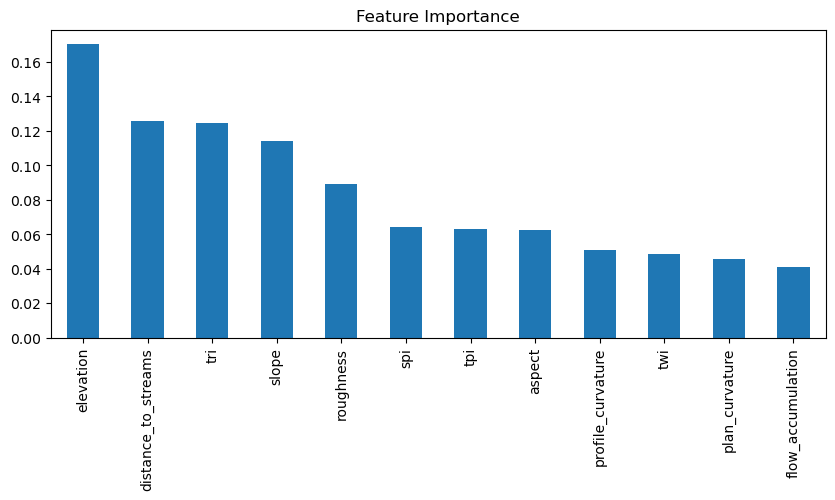

In [5]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.plot(kind="bar", figsize=(10,4), title="Feature Importance")
plt.show()


## Predict Raster

In [6]:
point_id = 1
factor_dir = os.path.join(stack_dir, f"aligned_factors_{point_id}")
files = sorted([f for f in os.listdir(factor_dir) if f.endswith(".tif")])

arrays = []
feature_names = []
profile = None
for f in files:
    with rasterio.open(os.path.join(factor_dir, f)) as src:
        if profile is None:
            profile = src.profile
        arrays.append(src.read(1))
        feature_names.append(os.path.splitext(f)[0])

arrays_ordered = [arrays[feature_names.index(col)] for col in X.columns]
stack = np.stack(arrays_ordered, axis=-1)
flat = stack.reshape(-1, stack.shape[-1])
mask = np.all(np.isfinite(flat), axis=1)

pred = np.zeros(flat.shape[0])
pred[mask] = rf.predict_proba(flat[mask])[:, 1]
out = pred.reshape(stack.shape[:2])

profile.update(dtype="float32", count=1, nodata=None)
out_path = os.path.join(stack_dir, f"susceptibility_rf_{point_id}.tif")
with rasterio.open(out_path, "w", **profile) as dst:
    dst.write(out.astype("float32"), 1)
print("Saved:", out_path)

/opt/conda/envs/pygile/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Saved: results/lsm_stack/susceptibility_rf_1.tif


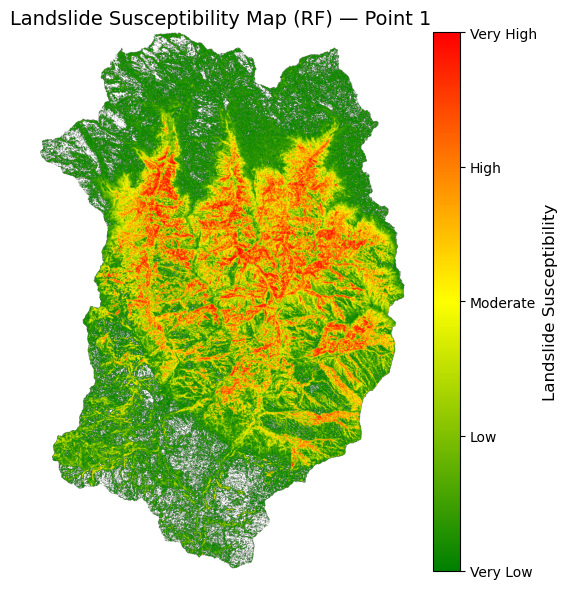

Saved: results/lsm_stack/susceptibility_rf_1.png


In [7]:
from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: green -> yellow -> red
cmap = LinearSegmentedColormap.from_list("lsm", ["green", "yellow", "red"])

fig, ax = plt.subplots(figsize=(8, 6))

# Mask zeros (no data areas)
out_masked = np.where(out == 0, np.nan, out)

im = ax.imshow(out_masked, cmap=cmap, vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Landslide Susceptibility", fontsize=12)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["Very Low", "Low", "Moderate", "High", "Very High"])

ax.set_title(f"Landslide Susceptibility Map (RF) — Point {point_id}", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
viz_path = os.path.join(stack_dir, f"susceptibility_rf_{point_id}.png")
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", viz_path)

                       AUC  Accuracy  Recall (Landslide)  \
Model                                                      
Logistic Regression  0.830     0.750               0.772   
Random Forest        0.906     0.834               0.885   

                     Precision (Landslide)  
Model                                       
Logistic Regression                  0.747  
Random Forest                        0.807  


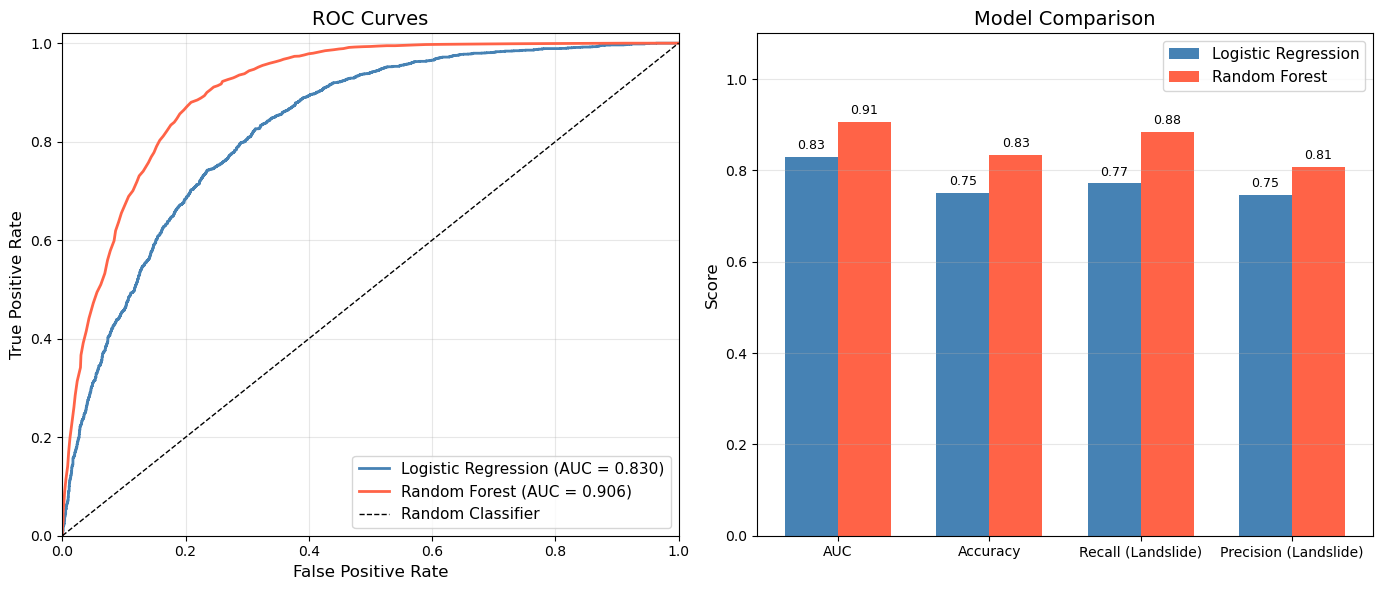

Saved: results/lsm_stack/model_comparison_1.png


In [8]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curves ---
models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
}
colors = ["steelblue", "tomato"]

ax = axes[0]
for (name, pred_prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, pred_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

# --- Metrics Comparison Bar Chart ---
metrics = {
    "Model": ["Logistic Regression", "Random Forest"],
    "AUC": [
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, rf_pred),
    ],
    "Accuracy": [
        ((lr_pred > 0.5).astype(int) == y_test).mean(),
        ((rf_pred > 0.5).astype(int) == y_test).mean(),
    ],
    "Recall (Landslide)": [
        classification_report(y_test, (lr_pred > 0.5).astype(int), output_dict=True)["1"]["recall"],
        classification_report(y_test, (rf_pred > 0.5).astype(int), output_dict=True)["1"]["recall"],
    ],
    "Precision (Landslide)": [
        classification_report(y_test, (lr_pred > 0.5).astype(int), output_dict=True)["1"]["precision"],
        classification_report(y_test, (rf_pred > 0.5).astype(int), output_dict=True)["1"]["precision"],
    ],
}

df_metrics = pd.DataFrame(metrics).set_index("Model")
print(df_metrics.round(3))

ax2 = axes[1]
x = np.arange(len(df_metrics.columns))
width = 0.35
bars1 = ax2.bar(x - width/2, df_metrics.loc["Logistic Regression"], width, label="Logistic Regression", color="steelblue")
bars2 = ax2.bar(x + width/2, df_metrics.loc["Random Forest"], width, label="Random Forest", color="tomato")

ax2.set_ylim(0, 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(df_metrics.columns, fontsize=10)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Model Comparison", fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
comparison_path = os.path.join(stack_dir, f"model_comparison_{point_id}.png")
plt.savefig(comparison_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", comparison_path)